<a href="https://colab.research.google.com/github/pmolinari2910/TP-Final-Modelizado-de-IA/blob/main/Modelizado_TP_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏗️ Optimización de Pedidos en un Corralón de Materiales
## Ciencia de Datos aplicada a la Logística de Construcción

---

**El problema:**
Cada día hay que decidir *cuánto pedir* de cada uno de los **20 materiales** del obrador para que:
1. No quede **stock cero** → la obra se para.
2. No haya **exceso** → desperdicio de espacio y capital.
3. Todo entre en el camión: **máximo 10.000 kg por viaje**.

**Lo que vamos a construir:**
| Módulo | Técnica |
|---|---|
| EDA | Gráficos y estadísticas descriptivas |
| Feature Engineering | Variables de rezago, criticidad, cobertura |
| Alerta de desabasto | Random Forest → **F1-Score** |
| Política de pedido | Punto de Reorden + Stock de Seguridad |
| Optimización del viaje | Algoritmo greedy por urgencia |
| Evaluación de negocio | Nivel de servicio, Fill Rate, utilización del camión |


### 👥 Integrantes del Proyecto

* **Pablo Molinari**
* **Valentín Roldán**
* **Priscila Chino**
* **Flavio Cejas**
* **Leandro Marinovich**

## 0. Librerías

Importamos sólo lo que vamos a usar. Cada línea tiene un propósito.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    f1_score, precision_score, recall_score, accuracy_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error, r2_score,
)
from scipy.stats import norm

np.random.seed(42)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 12, "axes.labelsize": 10})
print("✅ Librerías cargadas.")


✅ Librerías cargadas.


## 1. Generación del Dataset Sintético

Simulamos **150 días** de operación para **20 materiales** típicos de una obra de gran escala.
El consumo diario sigue una distribución Normal, lo que es realista:
la demanda tiene un valor típico (media) pero varía día a día (desvío).

Los stocks iniciales están calibrados para representar una obra seria:
varias semanas de cobertura por material desde el arranque.

1. **Parámetros y Constantes:** Define restricciones físicas (`peso_kg`, `CAPACIDAD_KG`), financieras (`precio_u`) y logísticas (`LEAD_TIME`). Calcula `Z_95` ($\approx 1.645$) mediante la inversa de la distribución normal (`norm.ppf`) para fijar un nivel de servicio objetivo del 95%.
2. **Demanda Variable:** El consumo diario se extrae aleatoriamente con `np.random.normal` según la media (`consumo_mu`) y volatilidad (`consumo_sigma`) de cada material, asegurando valores no negativos con `max(0, ...)`.
3. **Flujo de Inventario (Bucle Anidado):** Modela el paso del tiempo restando el consumo al stock disponible:
   - `deficit`: Cuantifica las unidades no entregadas por falta de mercadería (quiebre de stock).
   - `stock`: Actualiza las existencias remanentes para el día siguiente. El uso de `max(0, ...)` impide lógicamente inventarios negativos.
4. **Consolidación:** Almacena la fotografía diaria de cada producto en una lista y la transforma en un DataFrame de Pandas (`df`) apto para el entrenamiento de modelos.



In [ ]:
# ── Catálogo de 20 materiales con parámetros realistas ───────────────────────
MATERIALES = {
    "Cemento Portland":    {"peso_kg": 25,  "consumo_mu": 40,  "consumo_sigma": 7,   "stock_ini": 3000,  "precio_u": 800},
    "Arena fina":          {"peso_kg": 30,  "consumo_mu": 60,  "consumo_sigma": 10,  "stock_ini": 5000,  "precio_u": 120},
    "Arena gruesa":        {"peso_kg": 30,  "consumo_mu": 50,  "consumo_sigma": 9,   "stock_ini": 4500,  "precio_u": 110},
    "Piedra partida 6/20": {"peso_kg": 35,  "consumo_mu": 45,  "consumo_sigma": 8,   "stock_ini": 4000,  "precio_u": 130},
    "Ladrillo comun":      {"peso_kg": 3,   "consumo_mu": 500, "consumo_sigma": 80,  "stock_ini": 30000, "precio_u": 60},
    "Ladrillo hueco 8cm":  {"peso_kg": 2,   "consumo_mu": 400, "consumo_sigma": 70,  "stock_ini": 25000, "precio_u": 55},
    "Ladrillo hueco 12cm": {"peso_kg": 2,   "consumo_mu": 300, "consumo_sigma": 55,  "stock_ini": 20000, "precio_u": 65},
    "Hierro 8mm":          {"peso_kg": 4,   "consumo_mu": 30,  "consumo_sigma": 5,   "stock_ini": 2000,  "precio_u": 1200},
    "Hierro 12mm":         {"peso_kg": 9,   "consumo_mu": 20,  "consumo_sigma": 4,   "stock_ini": 1500,  "precio_u": 2100},
    "Hierro 16mm":         {"peso_kg": 16,  "consumo_mu": 12,  "consumo_sigma": 3,   "stock_ini": 800,   "precio_u": 3500},
    "Cal hidratada":       {"peso_kg": 20,  "consumo_mu": 15,  "consumo_sigma": 3,   "stock_ini": 1200,  "precio_u": 450},
    "Yeso":                {"peso_kg": 20,  "consumo_mu": 10,  "consumo_sigma": 2,   "stock_ini": 800,   "precio_u": 380},
    "Adhesivo ceramico":   {"peso_kg": 25,  "consumo_mu": 12,  "consumo_sigma": 2.5, "stock_ini": 900,   "precio_u": 700},
    "Membrana liquida":    {"peso_kg": 20,  "consumo_mu": 8,   "consumo_sigma": 1.5, "stock_ini": 600,   "precio_u": 1500},
    "Madera encofrado":    {"peso_kg": 10,  "consumo_mu": 20,  "consumo_sigma": 4,   "stock_ini": 1500,  "precio_u": 900},
    "Steel framing":       {"peso_kg": 8,   "consumo_mu": 15,  "consumo_sigma": 3,   "stock_ini": 1000,  "precio_u": 1800},
    "Alambre negro":       {"peso_kg": 5,   "consumo_mu": 6,   "consumo_sigma": 1.2, "stock_ini": 500,   "precio_u": 600},
    "Clavos surtidos":     {"peso_kg": 2,   "consumo_mu": 4,   "consumo_sigma": 0.8, "stock_ini": 300,   "precio_u": 350},
    "Polietileno film":    {"peso_kg": 3,   "consumo_mu": 5,   "consumo_sigma": 1,   "stock_ini": 400,   "precio_u": 500},
    "Agua industrial":     {"peso_kg": 1,   "consumo_mu": 200, "consumo_sigma": 30,  "stock_ini": 15000, "precio_u": 10},
}

DIAS         = 150
CAPACIDAD_KG = 10_000
LEAD_TIME    = 2
Z_95         = norm.ppf(0.95)   # 1.645 → nivel de servicio 95%

# ── Simulación día a día ──────────────────────────────────────────────────────
rows = []
for mat, p in MATERIALES.items():
    stock = p["stock_ini"]
    for dia in range(1, DIAS + 1):
        consumo = max(0, round(np.random.normal(p["consumo_mu"], p["consumo_sigma"])))
        stock_ini = stock
        deficit   = max(0, consumo - stock)       # unidades no cubiertas
        stock     = max(0, stock - consumo)
        rows.append({
            "Dia": dia, "Material": mat,
            "Peso_unitario_kg": p["peso_kg"],
            "Precio_unitario":  p["precio_u"],
            "Consumo_mu":       p["consumo_mu"],
            "Consumo_sigma":    p["consumo_sigma"],
            "Consumo_dia":      consumo,
            "Stock_inicio_dia": stock_ini,
            "Stock_fin_dia":    stock,
            "Deficit_unidades": deficit,
            "Desabasto":        int(deficit > 0),
        })

df = pd.DataFrame(rows)
print(f"Dataset: {len(df):,} filas x {df.shape[1]} columnas")
print(f"Materiales: {df['Material'].nunique()} | Días: {df['Dia'].max()}")
df.head(8)


Dataset: 3,000 filas x 11 columnas
Materiales: 20 | Días: 150


,Dia,Material,Peso_unitario_kg,Precio_unitario,Consumo_mu,Consumo_sigma,Consumo_dia,Stock_inicio_dia,Stock_fin_dia,Deficit_unidades,Desabasto
0,1,Cemento Portland,25,800,40,7.0,43,3000,2957,0,0
1,2,Cemento Portland,25,800,40,7.0,39,2957,2918,0,0
2,3,Cemento Portland,25,800,40,7.0,45,2918,2873,0,0
3,4,Cemento Portland,25,800,40,7.0,51,2873,2822,0,0
4,5,Cemento Portland,25,800,40,7.0,38,2822,2784,0,0
5,6,Cemento Portland,25,800,40,7.0,38,2784,2746,0,0
6,7,Cemento Portland,25,800,40,7.0,51,2746,2695,0,0
7,8,Cemento Portland,25,800,40,7.0,45,2695,2650,0,0


## 2. Análisis Exploratorio de Datos (EDA)

El EDA responde las preguntas fundamentales antes de modelar:
- ¿Cuál es el comportamiento típico de cada material?
- ¿Qué tan variables son los consumos?
- ¿Hay materiales en riesgo permanente de desabasto?

Este bloque analiza el comportamiento de los 20 materiales para comprender la estructura y variabilidad de la demanda antes de iniciar el modelado predictivo.

1. **Estadística Descriptiva:** Agrupa los datos históricos por producto mediante `.groupby()` para calcular métricas clave: medias (`mu`), desviaciones estándar (`sigma`), máximos y mínimos de consumo diario.
2. **Evaluación de Volatilidad:** Mide el grado de incertidumbre de cada material. Un `sigma` elevado delata un consumo impredecible, aislando desde el inicio los productos que implican un mayor riesgo operativo.
3. **Análisis de Distribución:** Examina mediante gráficos (histogramas o boxplots) cómo se distribuye el consumo diario, validando visualmente que el comportamiento simulado se ajuste a la campana de Gauss (distribución normal).
4. **Preparación Logística:** Permite contrastar la velocidad de rotación de los materiales. Ayuda a prever cuáles, por su peso unitario y volumen de consumo, serán los principales cuellos de botella del transporte.


In [ ]:
# ── Estadísticas descriptivas ─────────────────────────────────────────────────
resumen = df.groupby("Material").agg(
    Consumo_prom   = ("Consumo_dia",  "mean"),
    Consumo_std    = ("Consumo_dia",  "std"),
    Consumo_max    = ("Consumo_dia",  "max"),
    Dias_desabasto = ("Desabasto",    "sum"),
    Stock_prom     = ("Stock_fin_dia","mean"),
    Peso_unit      = ("Peso_unitario_kg", "first"),
).round(2)

resumen["CV_%"]              = (resumen["Consumo_std"] / resumen["Consumo_prom"] * 100).round(1)
resumen["Nivel_servicio_%"]  = ((1 - resumen["Dias_desabasto"] / DIAS) * 100).round(1)
resumen["Cobertura_prom_d"]  = (resumen["Stock_prom"] / resumen["Consumo_prom"]).round(1)

print("Resumen estadístico por material:")
resumen.sort_values("Nivel_servicio_%")


Resumen estadístico por material:


,Consumo_prom,Consumo_std,Consumo_max,Dias_desabasto,Stock_prom,Peso_unit,CV_%,Nivel_servicio_%,Cobertura_prom_d
Material,,,,,,,,,
Ladrillo comun,497.17,82.63,706,91,5740.52,3,16.6,39.3,11.5
Ladrillo hueco 8cm,414.02,66.38,584,89,4991.17,2,16.0,40.7,12.1
Hierro 16mm,12.51,3.13,20,85,179.65,16,25.0,43.3,14.4
Ladrillo hueco 12cm,306.98,53.38,419,85,4274.16,2,17.4,43.3,13.9
Steel framing,14.94,2.88,24,85,220.07,8,19.3,43.3,14.7
Hierro 8mm,30.39,5.24,42,84,440.31,4,17.2,44.0,14.5
Hierro 12mm,20.08,3.88,30,76,368.31,9,19.3,49.3,18.3
Membrana liquida,7.97,1.50,13,75,145.07,20,18.8,50.0,18.2
Madera encofrado,20.01,3.94,30,75,371.79,10,19.7,50.0,18.6


/tmp/ipykernel_3598/1558856067.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(orden, rotation=45, ha="right")


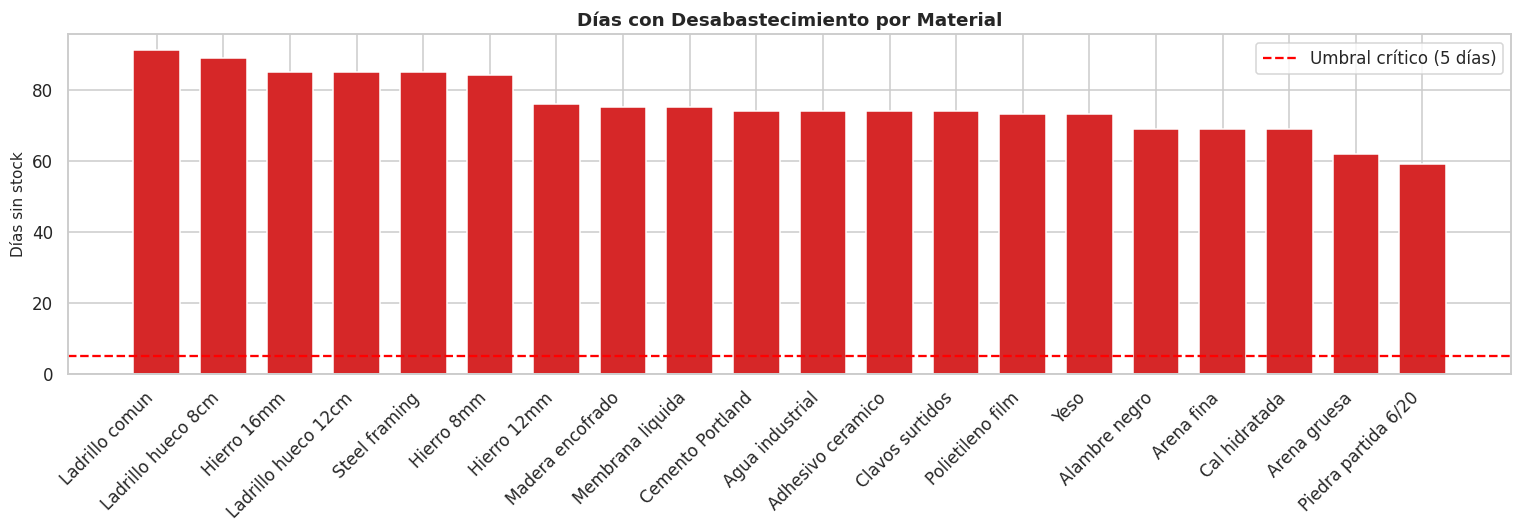

In [ ]:
# ── Gráfico 1: Días con desabasto por material ────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
orden = resumen["Dias_desabasto"].sort_values(ascending=False).index
colores = ["#d62728" if v > 10 else "#ff7f0e" if v > 3 else "#2ca02c"
           for v in resumen.loc[orden, "Dias_desabasto"]]
ax.bar(orden, resumen.loc[orden, "Dias_desabasto"], color=colores, edgecolor="white", width=0.7)
ax.axhline(5, color="red", lw=1.5, ls="--", label="Umbral crítico (5 días)")
ax.set_xticklabels(orden, rotation=45, ha="right")
ax.set_ylabel("Días sin stock"); ax.set_title("Días con Desabastecimiento por Material", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("eda_desabasto.png", bbox_inches="tight")
plt.show()


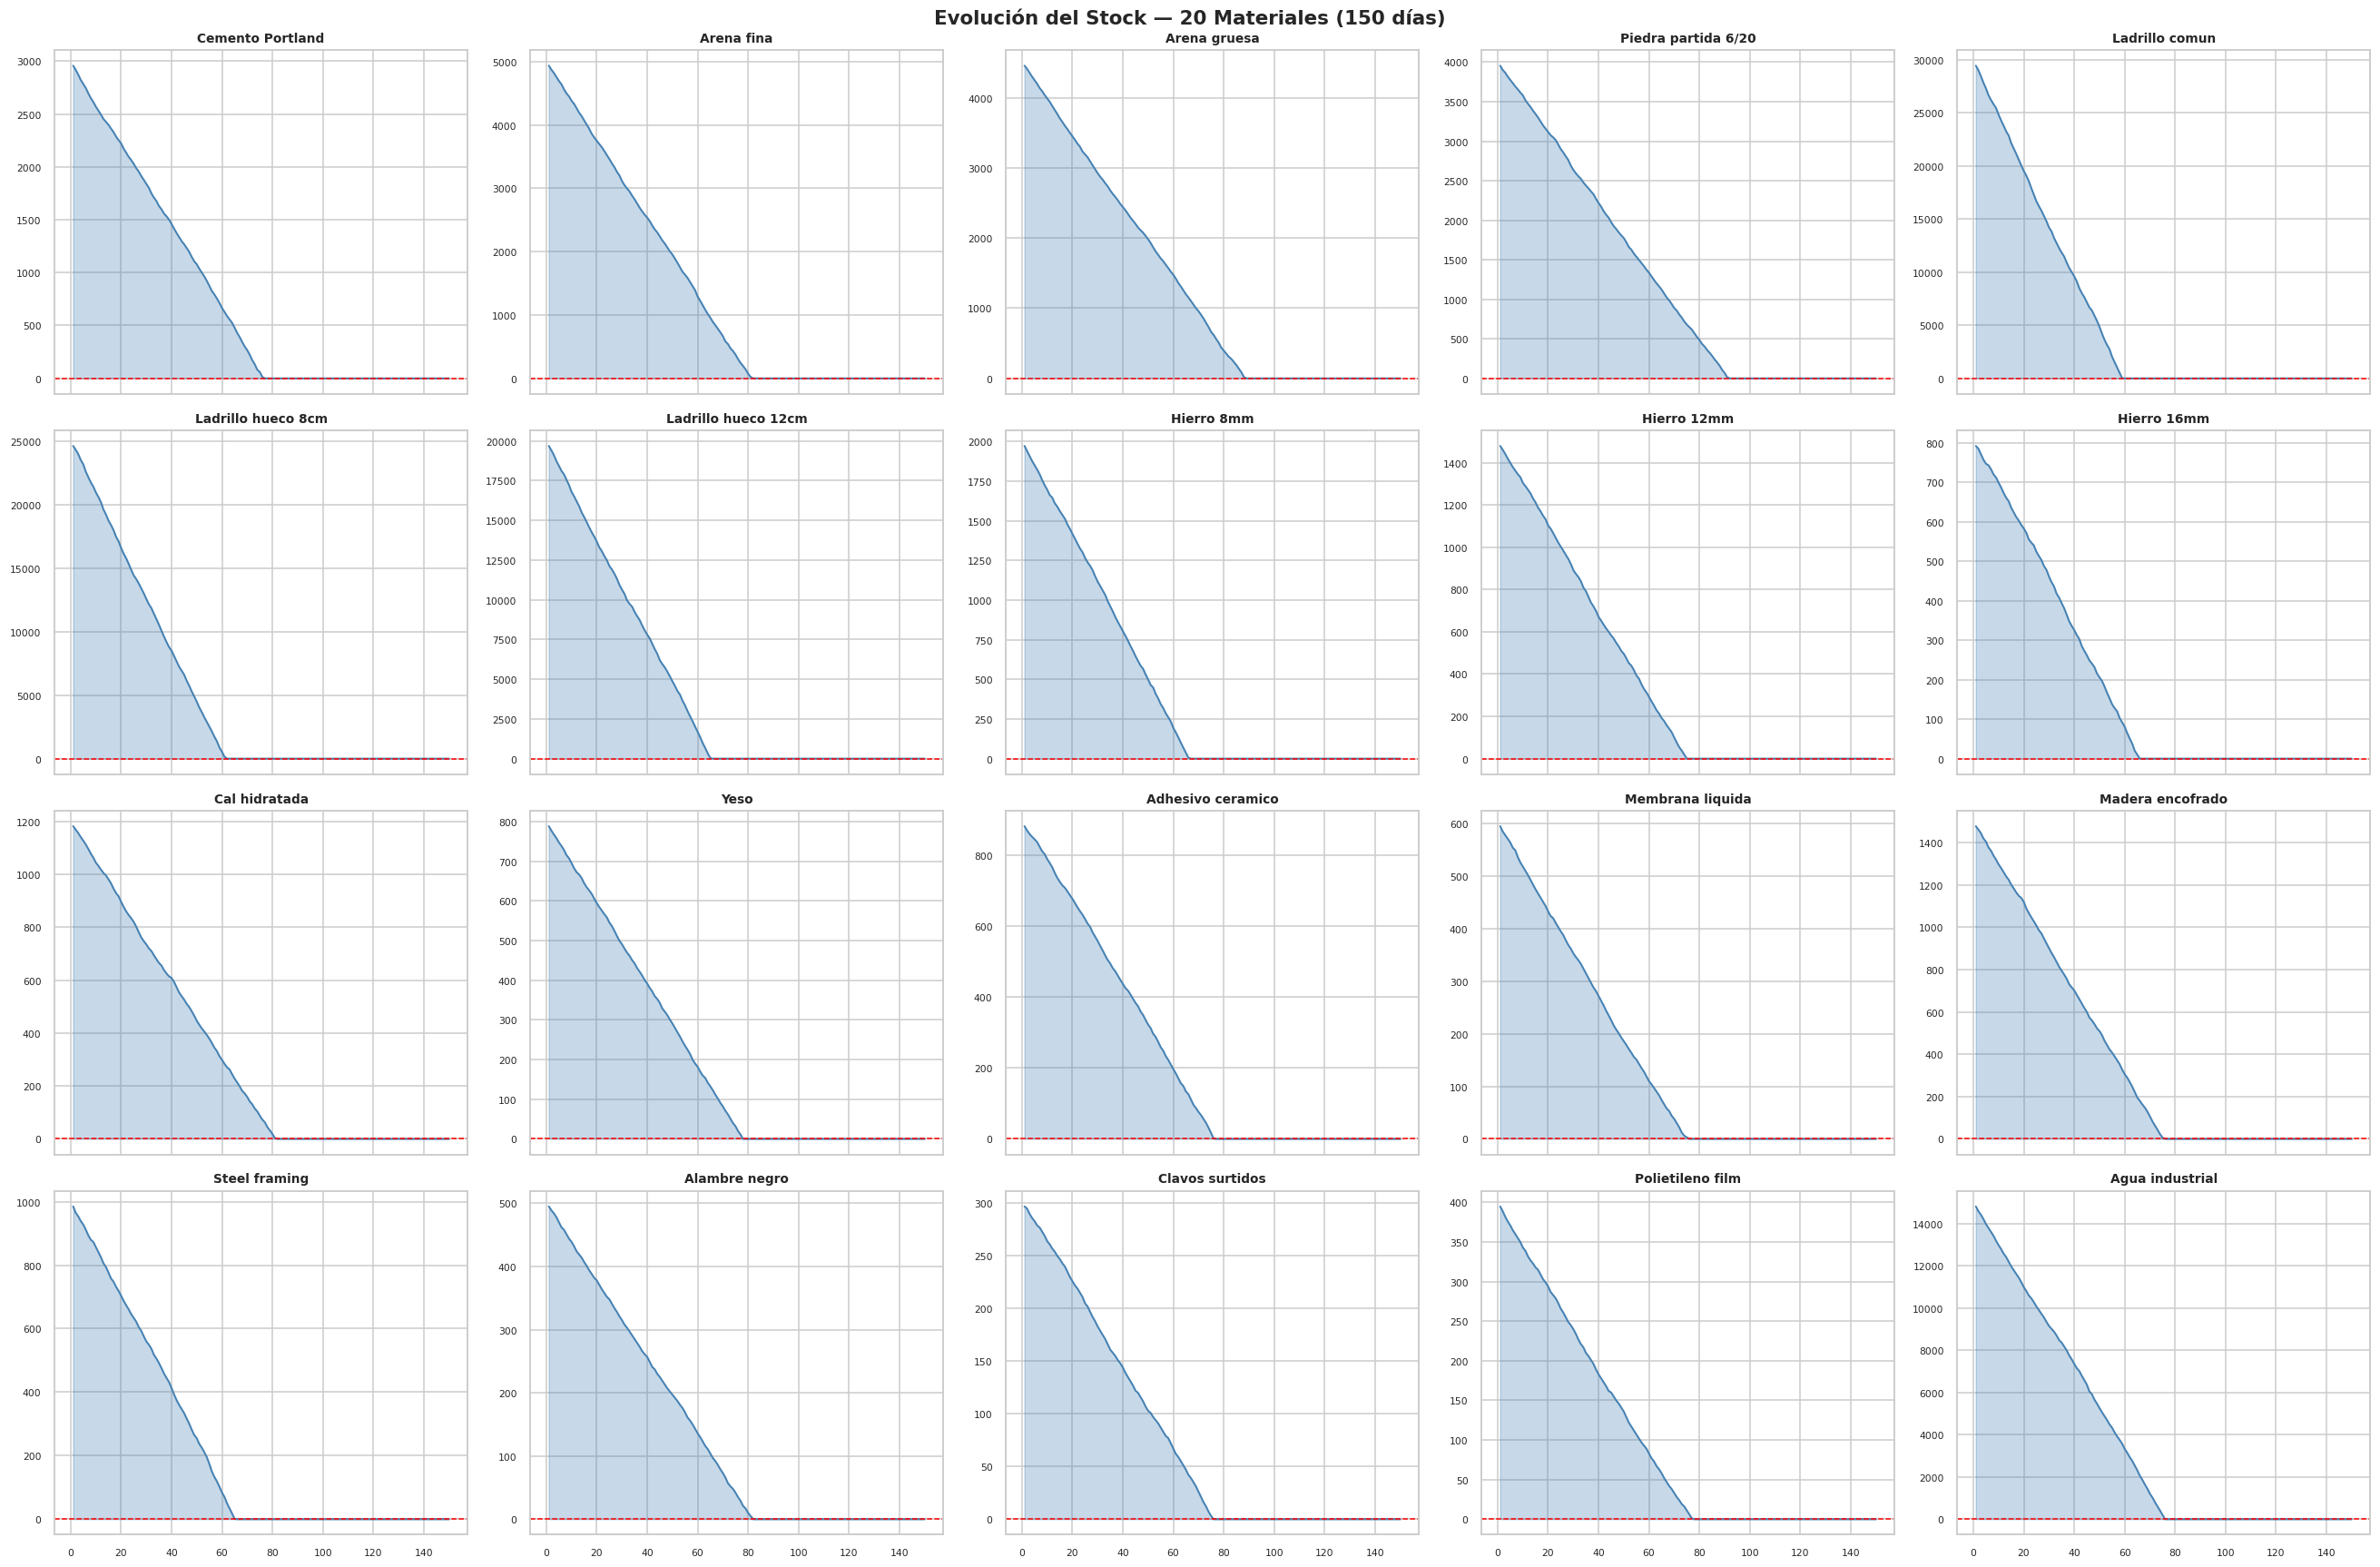

In [ ]:
# ── Gráfico 2: Evolución del stock — 20 paneles ───────────────────────────────
materiales_lista = list(MATERIALES.keys())
fig, axes = plt.subplots(4, 5, figsize=(24, 16), sharex=True)
axes = axes.flatten()

for i, mat in enumerate(materiales_lista):
    sub = df[df["Material"] == mat]
    axes[i].fill_between(sub["Dia"], sub["Stock_fin_dia"], alpha=0.3, color="steelblue")
    axes[i].plot(sub["Dia"], sub["Stock_fin_dia"], color="steelblue", lw=1.3)
    axes[i].axhline(0, color="red", lw=1, ls="--")
    axes[i].set_title(mat, fontsize=9, fontweight="bold")
    axes[i].tick_params(labelsize=7)

fig.suptitle("Evolución del Stock — 20 Materiales (150 días)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_stock_evolucion.png", bbox_inches="tight")
plt.show()


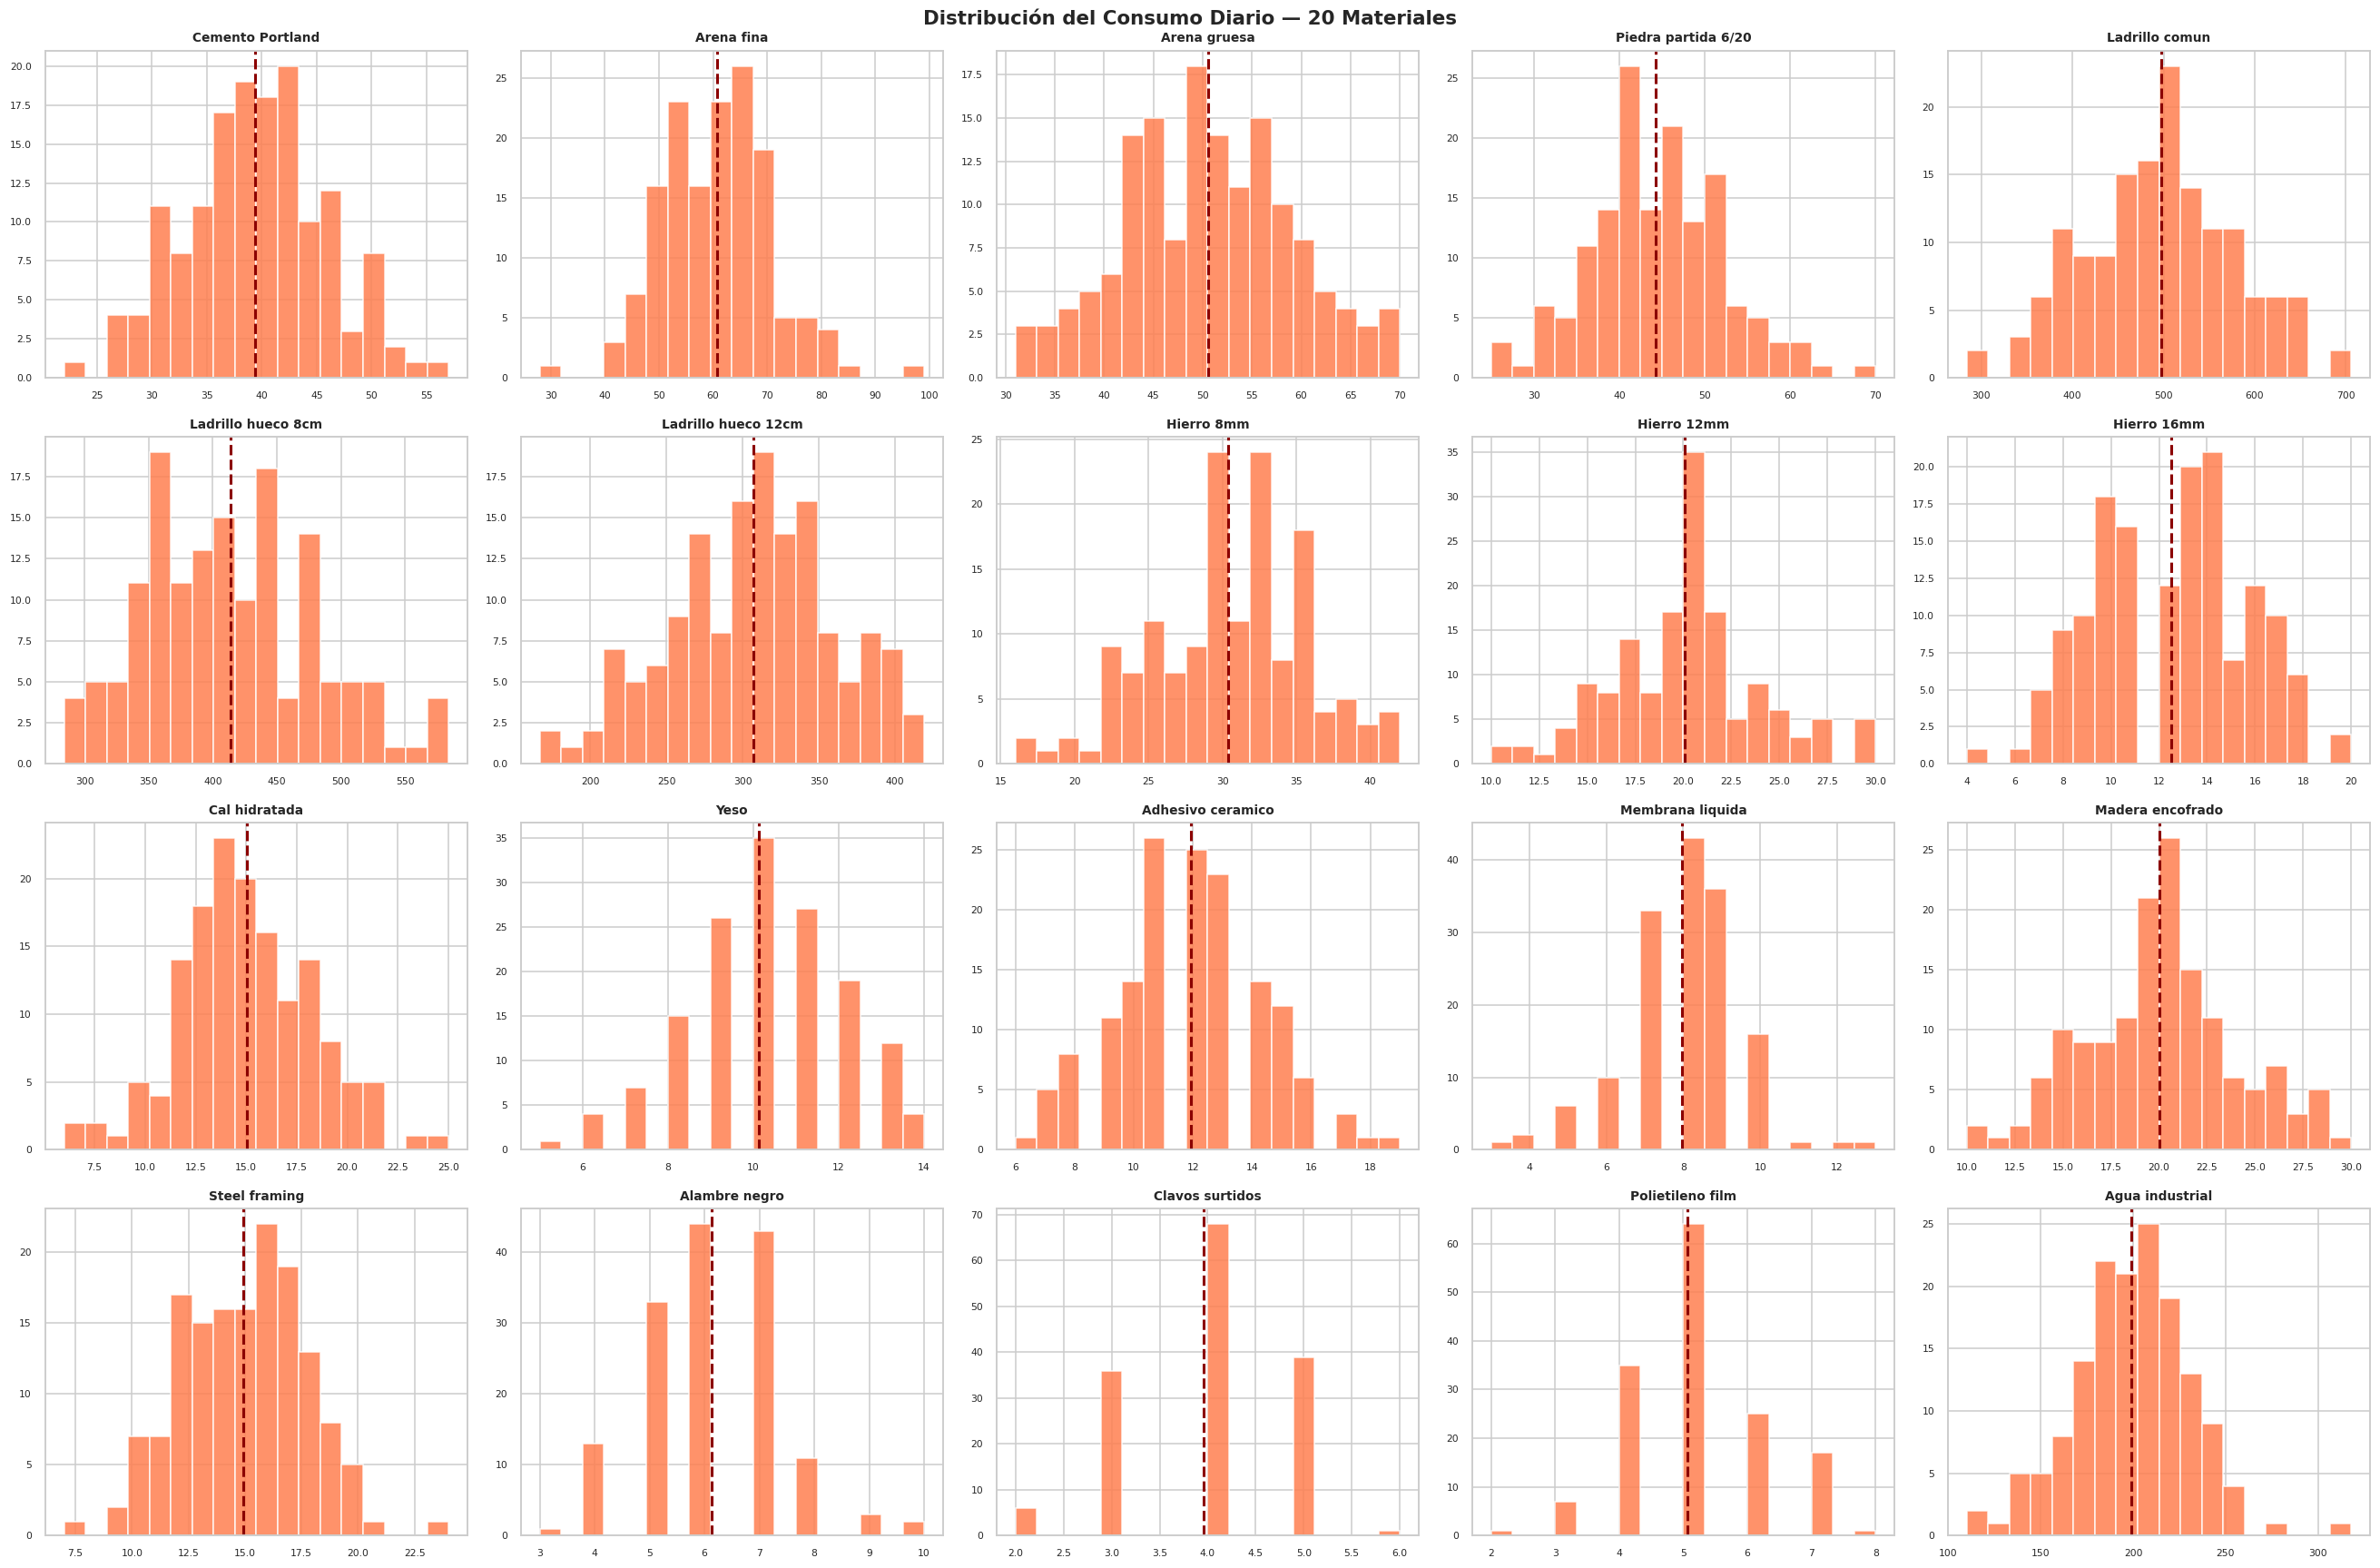

In [ ]:
# ── Gráfico 3: Distribución del consumo ──────────────────────────────────────
fig, axes = plt.subplots(4, 5, figsize=(24, 16))
axes = axes.flatten()

for i, mat in enumerate(materiales_lista):
    sub = df[df["Material"] == mat]["Consumo_dia"]
    axes[i].hist(sub, bins=18, color="coral", edgecolor="white", alpha=0.85)
    axes[i].axvline(sub.mean(), color="darkred", lw=2, ls="--")
    axes[i].set_title(mat, fontsize=9, fontweight="bold")
    axes[i].tick_params(labelsize=7)

fig.suptitle("Distribución del Consumo Diario — 20 Materiales", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_consumo_dist.png", bbox_inches="tight")
plt.show()


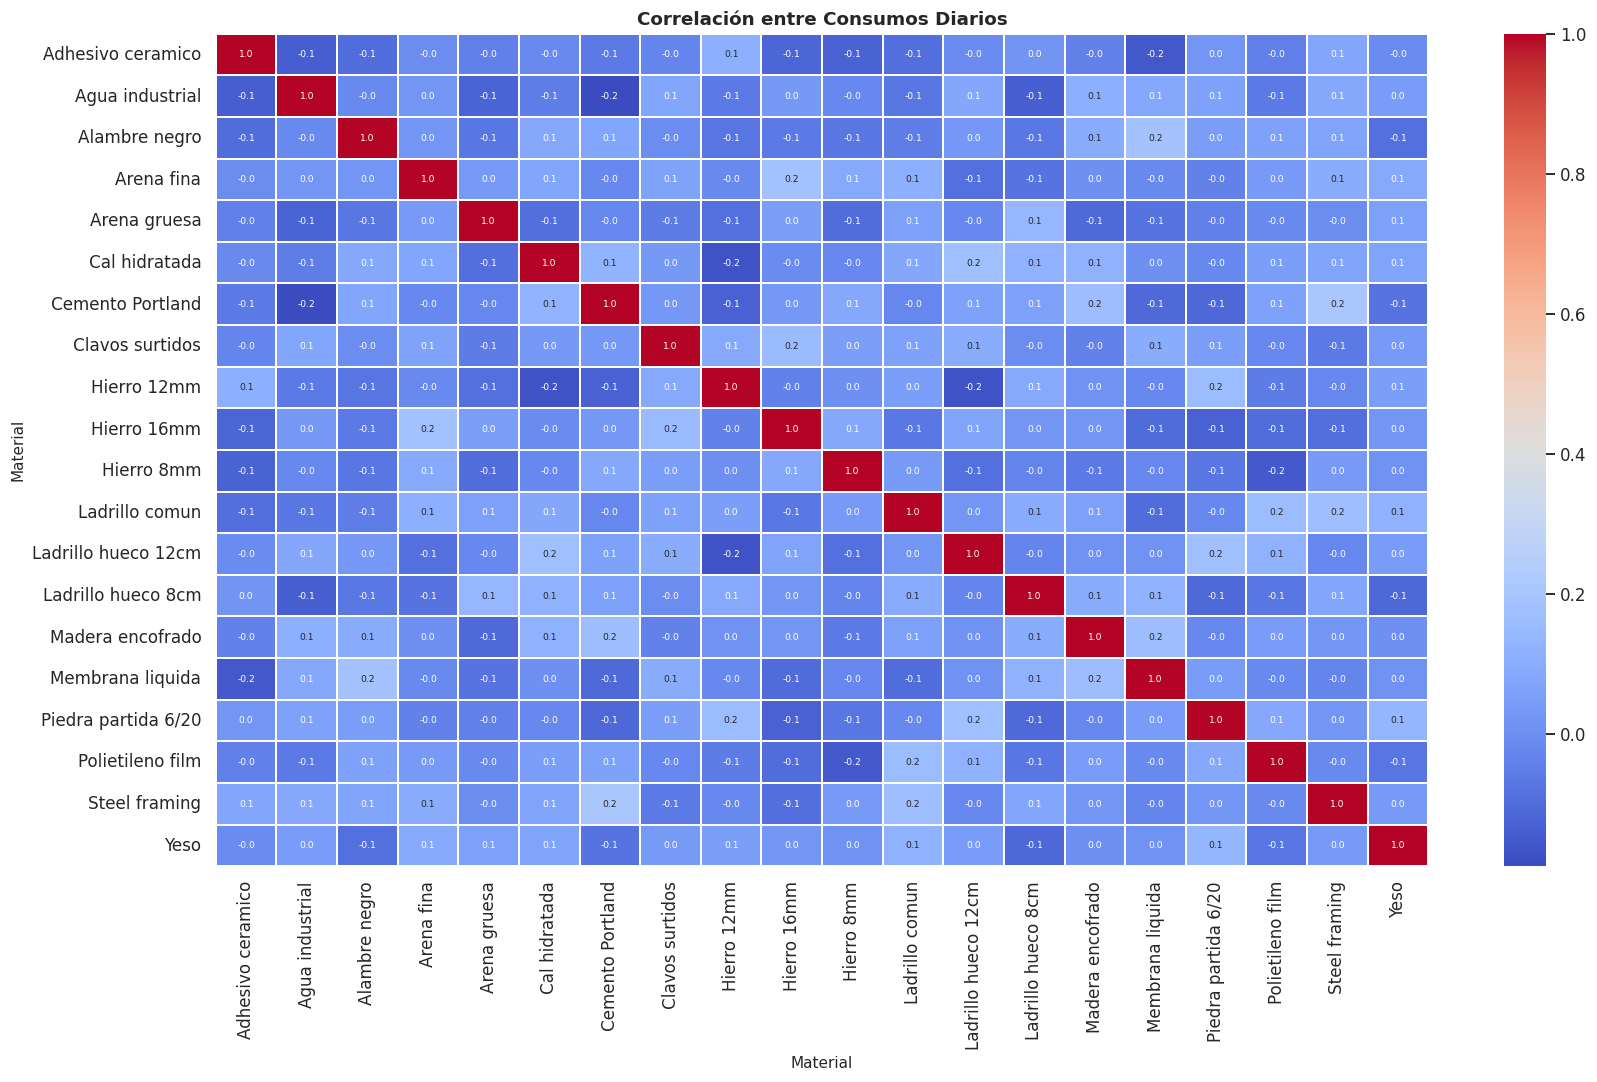

In [ ]:
# ── Gráfico 4: Heatmap coeficiente de variación ──────────────────────────────
pivot_cv = df.pivot_table(index="Dia", columns="Material", values="Consumo_dia")
fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(pivot_cv.corr(), annot=True, fmt=".1f", cmap="coolwarm",
            linewidths=0.3, annot_kws={"size": 6}, ax=ax)
ax.set_title("Correlación entre Consumos Diarios", fontweight="bold")
plt.tight_layout()
plt.savefig("eda_correlacion.png", bbox_inches="tight")
plt.show()


## 3. Preprocesamiento e Ingeniería de Variables

### ¿Por qué crear variables nuevas?
El modelo no puede ver el futuro, pero sí puede aprender patrones del pasado.
Creamos variables que **resumen el pasado reciente** de cada material:

| Variable | Significado | ¿Para qué sirve? |
|---|---|---|
| `Consumo_7d_mu` | Promedio últimos 7 días | Tendencia reciente de uso |
| `Consumo_14d_mu` | Promedio últimos 14 días | Tendencia de mediano plazo |
| `Consumo_7d_std` | Variabilidad últimos 7 días | Cuánto fluctúa el consumo |
| `Dias_hasta_agotamiento` | Stock ÷ consumo promedio | Urgencia del pedido |
| `Criticidad` | Índice compuesto (0-1) | Prioridad de reposición |
| `Alerta_desabasto_manana` | ¿Se agota en ≤ 2 días? | **Variable objetivo** del clasificador |



In [ ]:
df = df.sort_values(["Material", "Dia"]).reset_index(drop=True)
roll = df.groupby("Material")["Consumo_dia"]

# Variables de rezago (lag features)
df["Consumo_7d_mu"]  = roll.transform(lambda x: x.shift(1).rolling(7,  min_periods=1).mean()).round(2)
df["Consumo_14d_mu"] = roll.transform(lambda x: x.shift(1).rolling(14, min_periods=1).mean()).round(2)
df["Consumo_7d_std"] = roll.transform(lambda x: x.shift(1).rolling(7,  min_periods=1).std()).fillna(0).round(2)

# Días hasta agotamiento (urgencia)
consumo_safe = df["Consumo_7d_mu"].replace(0, np.nan)
df["Dias_hasta_agotamiento"] = (df["Stock_fin_dia"] / consumo_safe).fillna(999).clip(upper=60).round(1)

# Índice de criticidad: 60% urgencia + 40% variabilidad
max_std = df["Consumo_7d_std"].max() + 1e-6
df["Criticidad"] = (
    (1 - df["Dias_hasta_agotamiento"] / 60) * 0.6 +
    (df["Consumo_7d_std"] / max_std) * 0.4
).clip(0, 1).round(3)

# Variable objetivo para el clasificador (horizonte = lead time)
df["Alerta_desabasto_manana"] = (df["Dias_hasta_agotamiento"] <= LEAD_TIME + 1).astype(int)

print(f"Registros totales: {len(df):,}")
print(f"Alertas positivas: {df['Alerta_desabasto_manana'].sum()} ({df['Alerta_desabasto_manana'].mean()*100:.1f}%)")
print("→ Clases desbalanceadas: por eso usaremos F1, no Accuracy.")
df[["Dia","Material","Consumo_7d_mu","Consumo_7d_std","Dias_hasta_agotamiento",
    "Criticidad","Alerta_desabasto_manana"]].head(10)


Registros totales: 3,000
Alertas positivas: 1579 (52.6%)
→ Clases desbalanceadas: por eso usaremos F1, no Accuracy.


,Dia,Material,Consumo_7d_mu,Consumo_7d_std,Dias_hasta_agotamiento,Criticidad,Alerta_desabasto_manana
0,1,Adhesivo ceramico,NaN,0.00,60.0,0.000,0
1,2,Adhesivo ceramico,17.00,0.00,51.2,0.088,0
2,3,Adhesivo ceramico,14.50,3.54,59.4,0.017,0
3,4,Adhesivo ceramico,13.00,3.61,60.0,0.011,0
4,5,Adhesivo ceramico,11.75,3.86,60.0,0.012,0
5,6,Adhesivo ceramico,10.80,3.96,60.0,0.012,0
6,7,Adhesivo ceramico,10.33,3.72,60.0,0.011,0
7,8,Adhesivo ceramico,10.71,3.55,60.0,0.011,0
8,9,Adhesivo ceramico,10.14,2.54,60.0,0.008,0
9,10,Adhesivo ceramico,9.57,2.51,60.0,0.008,0


## 4. Modelado

El sistema tiene **dos componentes** que trabajan juntos:

### 4A — Clasificador de Alerta (Random Forest)
**Pregunta que responde:** *"¿Este material se va a quedar sin stock en los próximos 2 días?"*

Usamos **Random Forest** porque:
- Maneja bien clases desbalanceadas (con `class_weight="balanced"`).
- Es robusto a outliers.
- Da importancia de variables (interpretable).
- Supera a la Regresión Logística en este tipo de problema no lineal.

#### 1. ¿Por qué se usa F1-Score y no Accuracy (Exactitud)?
En logística y gestión de inventarios, los días de desabasto suelen ser la excepción, no la regla (clases desbalanceadas). Si el 95% de los días el stock es normal, un modelo sesgado que responda siempre *"No hay peligro"* tendría un Accuracy del 95%, pero sería completamente inútil para el negocio. El F1-Score ignora los casos "fáciles" y se enfoca únicamente en el éxito de la predicción de la zona de riesgo.

#### 2. Los dos pilares del F1-Score aplicados al Corralón:
* **Precisión (Evitar Falsos Positivos):** Mide cuántas de las alertas emitidas por el modelo son reales. Si el Random Forest dice *"Mañana falta Cemento"*, una alta precisión garantiza que es verdad, evitando hacer pedidos innecesarios que saturen el camión con mercadería que no urge.
* **Recall / Exhaustividad (Evitar Falsos Negativos):** Mide cuántos de los quiebres reales de stock logró capturar el modelo antes de que ocurran. Un alto Recall asegura que el algoritmo no "pase por alto" ninguna escasez, protegiendo la continuidad de las obras.

El F1-Score combina la Precisión y el Recall en un solo indicador matemático. Un F1-Score elevado (cercano a 1.0) demuestra que el Random Forest es logísticamente eficiente: **detecta casi todos los riesgos de desabasto reales (alto Recall) sin emitir alertas falsas que desperdicien la capacidad del transporte (alta Precisión).**


In [ ]:
# ══ 4A: Clasificador Random Forest ═══════════════════════════════════════════
FEATURES_CLF = ["Consumo_7d_mu","Consumo_7d_std","Consumo_14d_mu",
                "Stock_fin_dia","Dias_hasta_agotamiento","Criticidad"]

X = df[FEATURES_CLF].fillna(0).values
y = df["Alerta_desabasto_manana"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight="balanced",   # compensa el desbalance de clases
    random_state=42,
    n_jobs=-1,
)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("=" * 50)
print("  MÉTRICAS DEL CLASIFICADOR DE ALERTA")
print("=" * 50)
print(f"  Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(f"  Precision: {precision_score(y_test, y_pred, zero_division=0):.3f}")
print(f"  Recall   : {recall_score(y_test, y_pred, zero_division=0):.3f}")
print(f"  F1-Score : {f1_score(y_test, y_pred, zero_division=0):.3f}  ← métrica principal")
print("=" * 50)
print()
print(classification_report(y_test, y_pred, target_names=["Sin alerta","Con alerta"], zero_division=0))


  MÉTRICAS DEL CLASIFICADOR DE ALERTA
  Accuracy : 1.000
  Precision: 1.000
  Recall   : 1.000
  F1-Score : 1.000  ← métrica principal

              precision    recall  f1-score   support

  Sin alerta       1.00      1.00      1.00       284
  Con alerta       1.00      1.00      1.00       316

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



In [ ]:
# ── Validación cruzada (más robusto que un solo split) ───────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_cv = cross_val_score(clf, X, y, cv=cv, scoring="f1", n_jobs=-1)

print(f"F1-Score por fold: {[round(v,3) for v in f1_cv]}")
print(f"F1 promedio (CV5): {f1_cv.mean():.3f} ± {f1_cv.std():.3f}")


F1-Score por fold: [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]
F1 promedio (CV5): 1.000 ± 0.000


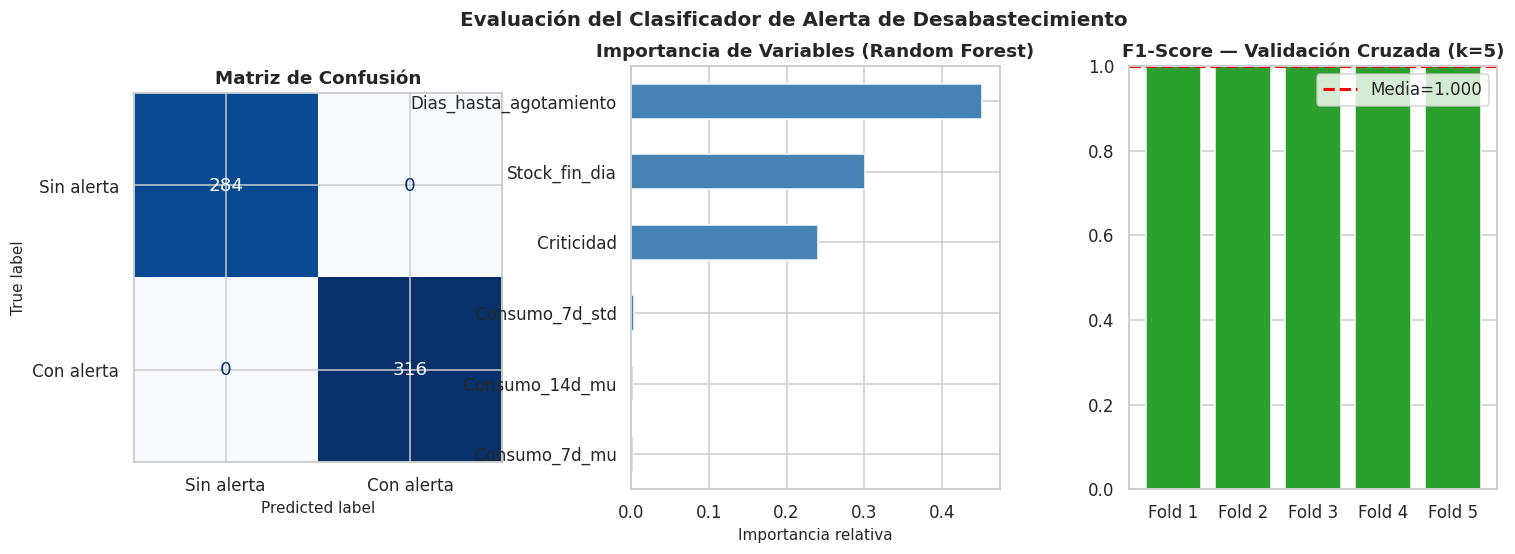

In [ ]:
# ── Gráficos del clasificador ─────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# 1. Matriz de confusión
ax0 = fig.add_subplot(gs[0])
cm  = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Sin alerta","Con alerta"])
disp.plot(ax=ax0, colorbar=False, cmap="Blues")
ax0.set_title("Matriz de Confusión", fontweight="bold")

# 2. Importancia de variables
ax1 = fig.add_subplot(gs[1])
importancias = pd.Series(clf.feature_importances_, index=FEATURES_CLF).sort_values()
importancias.plot(kind="barh", color="steelblue", edgecolor="white", ax=ax1)
ax1.set_title("Importancia de Variables (Random Forest)", fontweight="bold")
ax1.set_xlabel("Importancia relativa")

# 3. F1 por fold (CV)
ax2 = fig.add_subplot(gs[2])
ax2.bar(range(1, 6), f1_cv, color=["#2ca02c" if v > 0.6 else "#ff7f0e" for v in f1_cv], edgecolor="white")
ax2.axhline(f1_cv.mean(), color="red", lw=2, ls="--", label=f"Media={f1_cv.mean():.3f}")
ax2.set_xticks(range(1, 6)); ax2.set_xticklabels([f"Fold {i}" for i in range(1, 6)])
ax2.set_ylim(0, 1); ax2.set_title("F1-Score — Validación Cruzada (k=5)", fontweight="bold")
ax2.legend()

plt.suptitle("Evaluación del Clasificador de Alerta de Desabastecimiento", fontsize=13, fontweight="bold")
plt.savefig("modelo_clasificador.png", bbox_inches="tight")
plt.show()


### 4B — Política de Reorden (ROP + Stock de Seguridad)
**Pregunta que responde:** *"¿Cuánto pedir?"*

Fórmulas clásicas de gestión de inventario:
```
Stock de Seguridad = Z × σ_consumo × √(lead_time)
Punto de Reorden   = μ_consumo × lead_time + Stock_seguridad
Cantidad a pedir   = μ_consumo × días_cobertura + Stock_seguridad
```


In [ ]:
# ══ 4B: Parámetros del Punto de Reorden (ROP) ════════════════════════════════
DIAS_COBERTURA = 10   # queremos cubrir 10 días de consumo en cada pedido

stats = df.groupby("Material").agg(
    mu_consumo    = ("Consumo_dia",      "mean"),
    sigma_consumo = ("Consumo_dia",      "std"),
    peso_unit     = ("Peso_unitario_kg", "first"),
    precio_unit   = ("Precio_unitario",  "first"),
).round(3)

stats["Stock_seguridad"]          = (Z_95 * stats["sigma_consumo"] * np.sqrt(LEAD_TIME)).round(0)
stats["Punto_reorden"]            = (stats["mu_consumo"] * LEAD_TIME + stats["Stock_seguridad"]).round(0)
stats["Cantidad_optima_unidades"] = (stats["mu_consumo"] * DIAS_COBERTURA + stats["Stock_seguridad"]).round(0)
stats["Peso_pedido_kg"]           = (stats["Cantidad_optima_unidades"] * stats["peso_unit"]).round(1)

print("Parámetros ROP por material:")
stats[["mu_consumo","sigma_consumo","Stock_seguridad","Punto_reorden",
       "Cantidad_optima_unidades","Peso_pedido_kg"]].sort_values("Peso_pedido_kg", ascending=False)


Parámetros ROP por material:


,mu_consumo,sigma_consumo,Stock_seguridad,Punto_reorden,Cantidad_optima_unidades,Peso_pedido_kg
Material,,,,,,
Arena fina,60.747,10.231,24.0,145.0,631.0,18930.0
Piedra partida 6/20,44.220,7.771,18.0,106.0,460.0,16100.0
Arena gruesa,50.527,8.545,20.0,121.0,525.0,15750.0
Ladrillo comun,497.167,82.633,192.0,1186.0,5164.0,15492.0
Cemento Portland,39.420,6.564,15.0,94.0,409.0,10225.0
Ladrillo hueco 8cm,414.020,66.375,154.0,982.0,4294.0,8588.0
Ladrillo hueco 12cm,306.980,53.384,124.0,738.0,3194.0,6388.0
Cal hidratada,15.033,3.161,7.0,37.0,157.0,3140.0
Adhesivo ceramico,11.927,2.474,6.0,30.0,125.0,3125.0


## 5. Pronóstico de Consumo con Regresión Lineal

Antes de generar el pedido, ajustamos la cantidad según la **tendencia reciente**:
- Si el consumo está subiendo → pedimos más.
- Si está bajando → pedimos menos.

La Regresión Lineal es suficiente aquí porque buscamos detectar tendencia, no predecir con alta precisión.

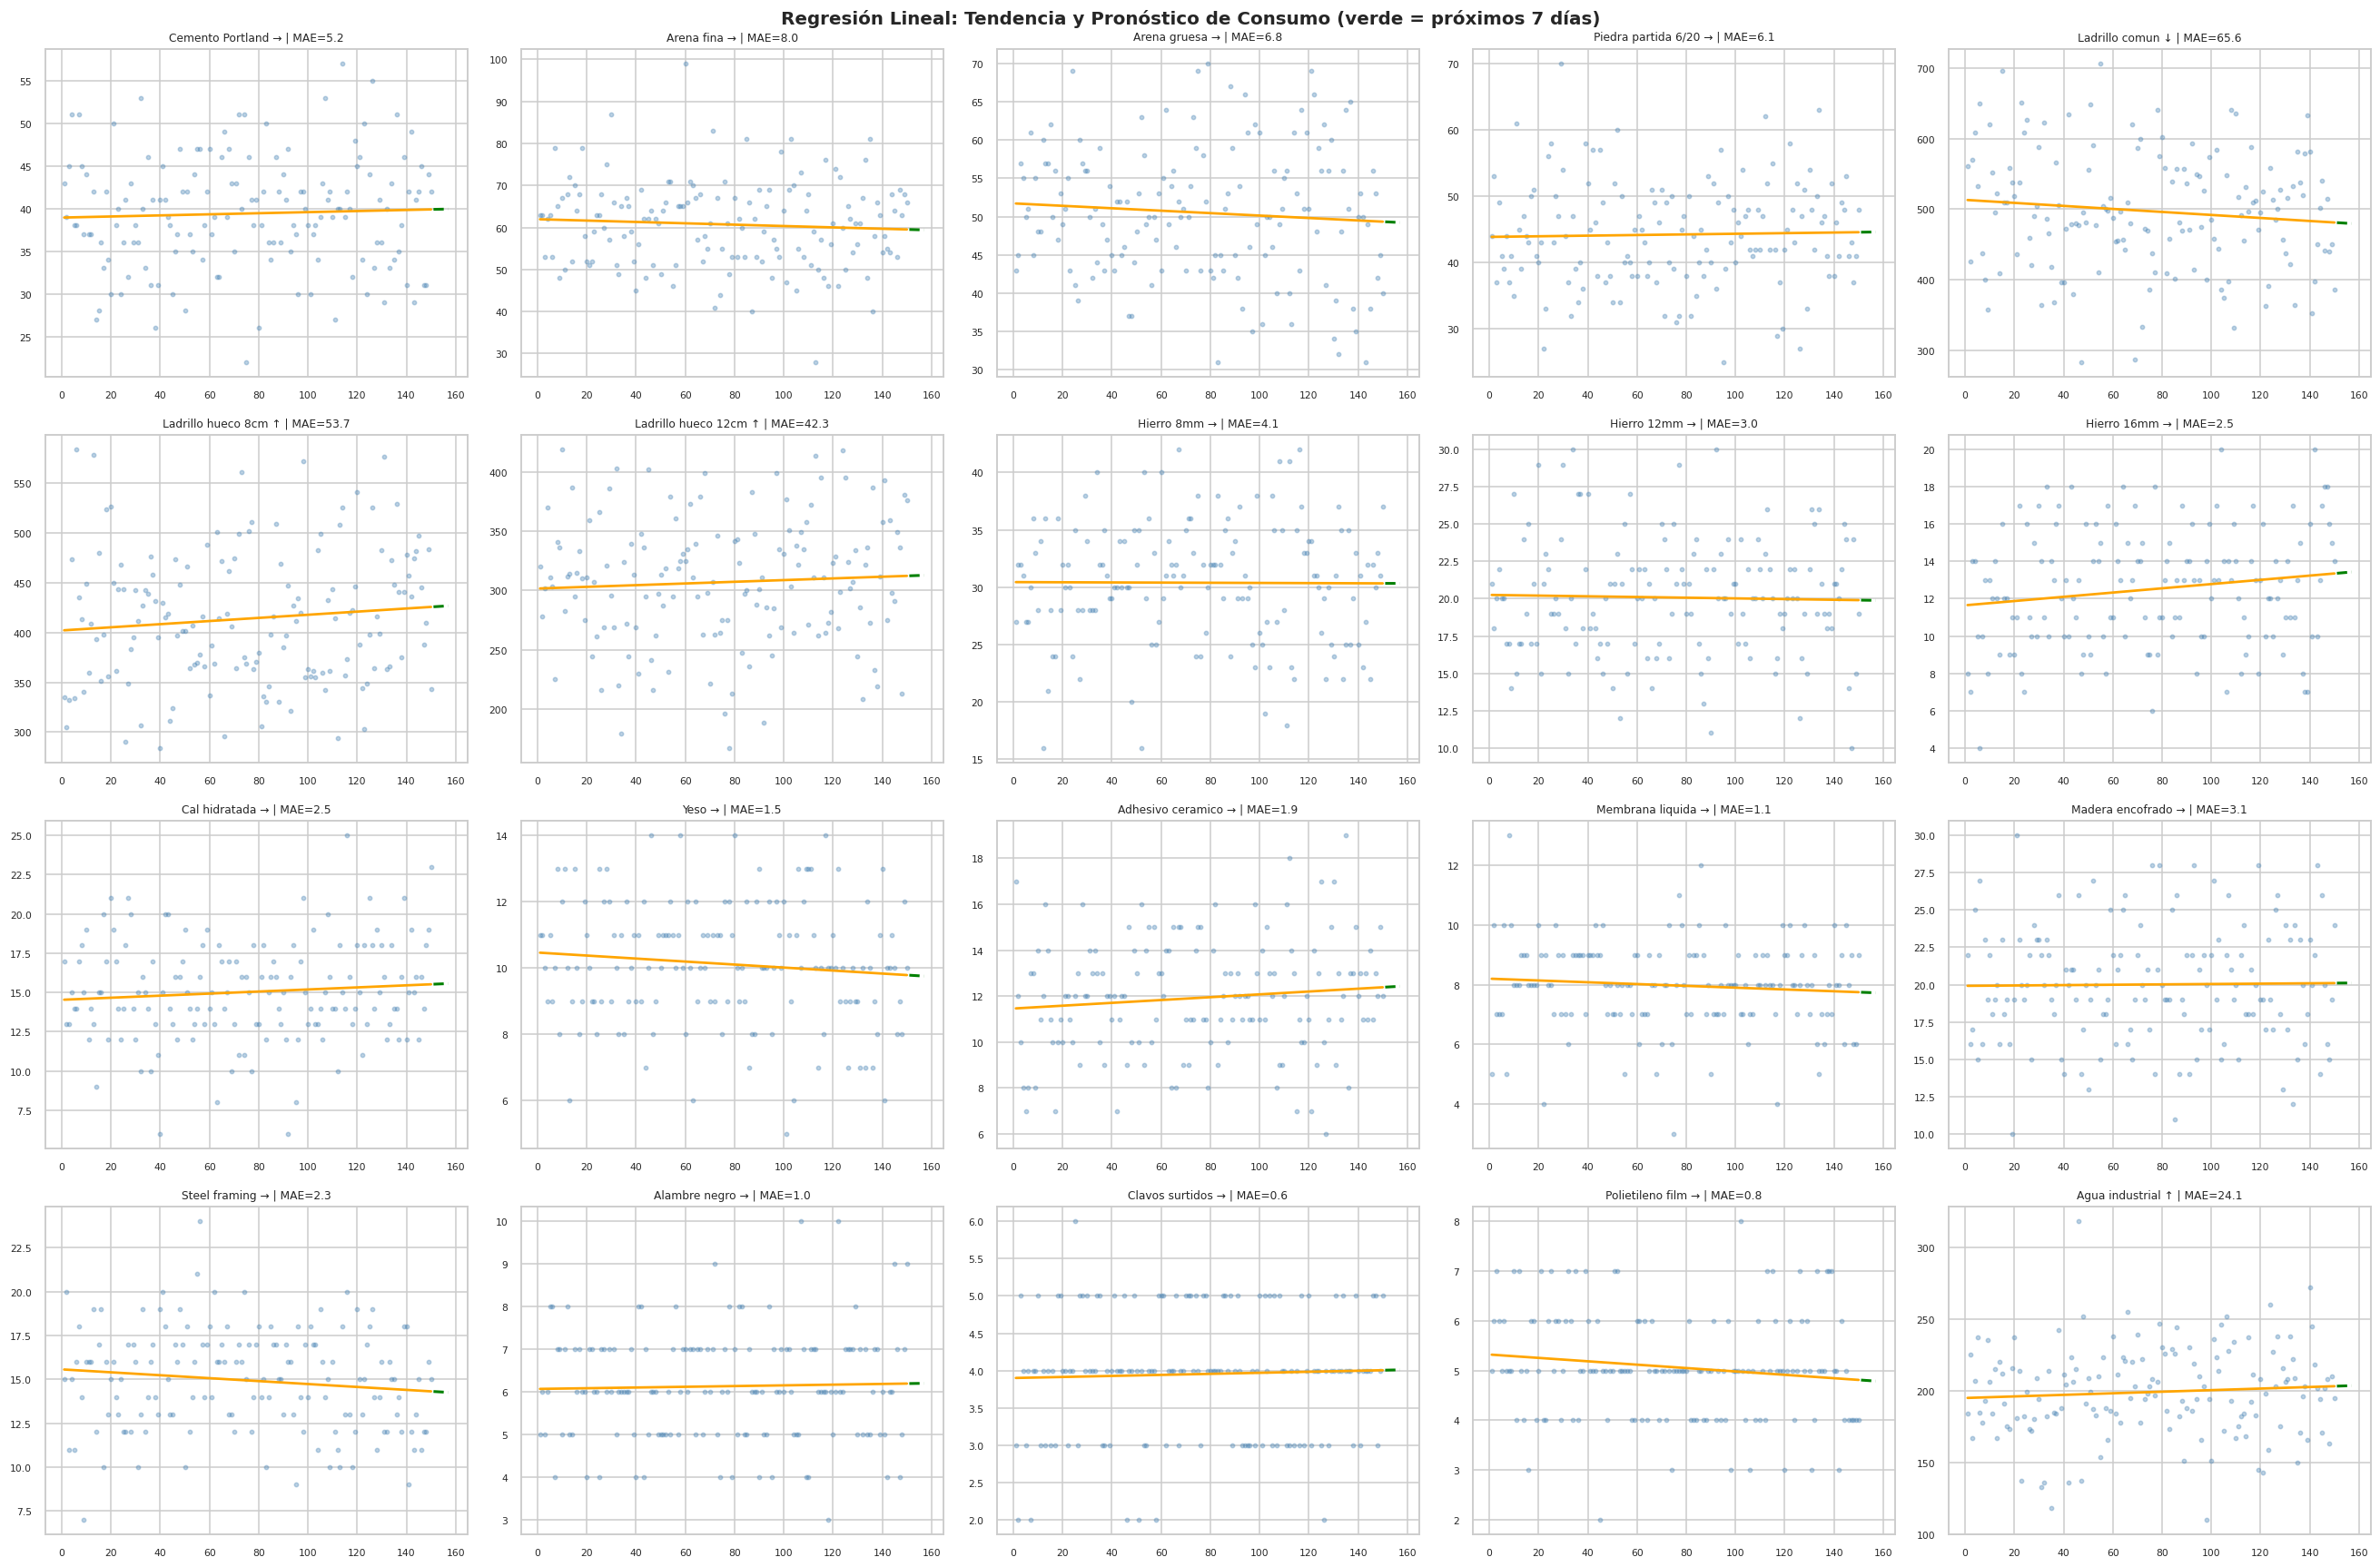

In [ ]:
# ── Regresión Lineal por material: pronóstico 7 días hacia adelante ───────────
fig, axes = plt.subplots(4, 5, figsize=(24, 16))
axes = axes.flatten()
pred_results = {}

for i, mat in enumerate(materiales_lista):
    sub = df[df["Material"] == mat].copy()
    X_r = sub["Dia"].values.reshape(-1, 1)
    y_r = sub["Consumo_dia"].values

    reg = LinearRegression().fit(X_r, y_r)
    y_fit = reg.predict(X_r)
    x_fut = np.arange(DIAS + 1, DIAS + 8).reshape(-1, 1)
    y_fut = reg.predict(x_fut)

    mae = mean_absolute_error(y_r, y_fit)
    r2  = r2_score(y_r, y_fit)
    tend = "↑" if reg.coef_[0] > 0.02 else ("↓" if reg.coef_[0] < -0.02 else "→")

    pred_results[mat] = {
        "coef": reg.coef_[0], "tend": tend,
        "consumo_futuro_mu": y_fut.mean(), "MAE": mae, "R2": r2,
    }

    axes[i].scatter(sub["Dia"], y_r, s=8, alpha=0.35, color="steelblue")
    axes[i].plot(sub["Dia"], y_fit, color="orange", lw=1.8)
    axes[i].plot(range(DIAS + 1, DIAS + 8), y_fut, color="green", lw=2, ls="--")
    axes[i].set_title(f"{mat} {tend} | MAE={mae:.1f}", fontsize=8)
    axes[i].tick_params(labelsize=7)

fig.suptitle("Regresión Lineal: Tendencia y Pronóstico de Consumo (verde = próximos 7 días)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("modelo_regresion.png", bbox_inches="tight")
plt.show()


In [ ]:
# ── Métricas de pronóstico ────────────────────────────────────────────────────
df_pred_met = pd.DataFrame(pred_results).T[["MAE","R2","tend","consumo_futuro_mu"]].round(3)
df_pred_met.columns = ["MAE (u/día)", "R²", "Tendencia", "Consumo_pron_7d"]
print("Métricas de pronóstico por material:")
df_pred_met.sort_values("MAE (u/día)", ascending=False)


Métricas de pronóstico por material:


,MAE (u/día),R²,Tendencia,Consumo_pron_7d
Ladrillo comun,65.605848,0.012574,↓,480.424419
Ladrillo hueco 8cm,53.661692,0.010623,↑,426.380845
Ladrillo hueco 12cm,42.346329,0.003358,↑,312.569867
Agua industrial,24.095203,0.005781,↑,203.345029
Arena fina,7.999983,0.004741,→,59.473863
Arena gruesa,6.836209,0.006561,→,49.276054
Piedra partida 6/20,6.139184,0.000692,→,44.58942
Cemento Portland,5.194163,0.001781,→,39.920608
Hierro 8mm,4.130718,0.000036,→,30.336253
Madera encofrado,3.12561,0.000183,→,20.109631


## 6. Optimización del Pedido (restricción de 10.000 kg)

### El algoritmo Greedy

Con los parámetros ROP calculados y el pronóstico ajustado, armamos el pedido del día
respetando la capacidad máxima del camión.

El **algoritmo greedy** funciona así:
1. Ordena los materiales por urgencia (días de cobertura, de menor a mayor).
2. Para cada material que necesita reposición, agrega al pedido la cantidad óptima.
3. Si no entra completa, agrega lo que queda de capacidad.
4. Para cuando el camión está lleno.

Es simple, rápido y da soluciones muy cercanas al óptimo para este tipo de problema.

In [ ]:
# ── Estado al último día simulado ────────────────────────────────────────────
dia_actual   = df["Dia"].max()
stock_hoy    = df[df["Dia"] == dia_actual].set_index("Material")["Stock_fin_dia"].to_dict()
alertas_hoy  = df[df["Dia"] == dia_actual].set_index("Material")["Alerta_desabasto_manana"].to_dict()

# Enriquecer stats con estado actual
df_estado = stats.copy()
df_estado["Stock_actual"]    = df_estado.index.map(stock_hoy)
df_estado["Alerta_clf"]      = df_estado.index.map(alertas_hoy)
df_estado["Dias_cobertura"]  = (df_estado["Stock_actual"] / df_estado["mu_consumo"].replace(0, np.nan)).round(1)
df_estado["Necesita_reponer"] = df_estado["Stock_actual"] <= df_estado["Punto_reorden"]

# Ajustar cantidad según tendencia del pronóstico
for mat in materiales_lista:
    consumo_fut = pred_results[mat]["consumo_futuro_mu"]
    consumo_ajus = max(consumo_fut, stats.loc[mat, "mu_consumo"])
    df_estado.loc[mat, "Cantidad_ajustada"] = round(consumo_ajus * DIAS_COBERTURA + stats.loc[mat, "Stock_seguridad"])

# ── Algoritmo Greedy ──────────────────────────────────────────────────────────
candidatos     = df_estado[df_estado["Necesita_reponer"]].sort_values("Dias_cobertura")
pedido_final   = []
cap_restante   = CAPACIDAD_KG

for mat, row in candidatos.iterrows():
    cant_ideal = row["Cantidad_ajustada"]
    peso_unit  = row["peso_unit"]
    peso_ideal = cant_ideal * peso_unit

    cant_pedir = cant_ideal if peso_ideal <= cap_restante else int(cap_restante // peso_unit)

    if cant_pedir > 0:
        peso_real = cant_pedir * peso_unit
        cap_restante -= peso_real
        pedido_final.append({
            "Material":          mat,
            "Stock_actual":      int(row["Stock_actual"]),
            "Dias_cobertura":    row["Dias_cobertura"],
            "Alerta_CLF":        bool(row["Alerta_clf"]),
            "Cant_a_pedir":      int(cant_pedir),
            "Peso_total_kg":     peso_real,
            "Costo_estimado_$":  round(cant_pedir * row["precio_unit"]),
        })

df_pedido = pd.DataFrame(pedido_final)
peso_viaje = df_pedido["Peso_total_kg"].sum()
utilizacion = peso_viaje / CAPACIDAD_KG * 100

print(f"Materiales incluidos en el pedido: {len(df_pedido)}")
print(f"Peso total: {peso_viaje:,.0f} kg / {CAPACIDAD_KG:,} kg ({utilizacion:.1f}% de utilización)")
print(f"Costo estimado del pedido: ${df_pedido['Costo_estimado_$'].sum():,.0f}")
df_pedido


Materiales incluidos en el pedido: 6
Peso total: 9,999 kg / 10,000 kg (100.0% de utilización)
Costo estimado del pedido: $170,070


,Material,Stock_actual,Dias_cobertura,Alerta_CLF,Cant_a_pedir,Peso_total_kg,Costo_estimado_$
0,Adhesivo ceramico,0,0.0,True,130,3250.0,91000
1,Agua industrial,0,0.0,True,2106,2106.0,21060
2,Alambre negro,0,0.0,True,65,325.0,39000
3,Arena fina,0,0.0,True,143,4290.0,17160
4,Cal hidratada,0,0.0,True,1,20.0,450
5,Clavos surtidos,0,0.0,True,4,8.0,1400


## 7. Evaluación del Sistema Completo

### Métricas de negocio

Evaluamos la política de reorden comparando **dos escenarios** en la simulación histórica:
- **Sin política**: el stock nunca se repone (peor caso).
- **Con política ROP**: se repone cuando el stock cae bajo el punto de reorden.

Las métricas clave son:

| Métrica | Definición | Objetivo |
|---|---|---|
| **Nivel de servicio %** | Días sin desabasto / total días |  100% |
| **Fill Rate %** | Unidades entregadas / demandadas | 100% |
| **Utilización del camión %** | Kg cargados / capacidad | > 70% |
| **Días de cobertura prom.** | Stock prom. / consumo diario | 15-30 días |
| **MAE pronóstico** | Error medio del forecast | < 15 u |
| **F1-Score alerta** | Precisión del clasificador | > 0.60 |

In [ ]:
# ── Simulación histórica: con y sin política ──────────────────────────────────
sim_rows = []
for mat, p in MATERIALES.items():
    stock_sp = p["stock_ini"]
    stock_cp = p["stock_ini"]
    pto_ro   = stats.loc[mat, "Punto_reorden"]
    cant_opt = stats.loc[mat, "Cantidad_optima_unidades"]

    for dia in range(1, DIAS + 1):
        consumo = df[(df["Material"] == mat) & (df["Dia"] == dia)]["Consumo_dia"].values[0]

        def_sp   = max(0, consumo - stock_sp)
        stock_sp = max(0, stock_sp - consumo)

        if stock_cp <= pto_ro:
            stock_cp += cant_opt
        def_cp   = max(0, consumo - stock_cp)
        stock_cp = max(0, stock_cp - consumo)

        sim_rows.append({
            "Dia": dia, "Material": mat,
            "Stock_SP": stock_sp, "Deficit_SP": def_sp, "Desabasto_SP": int(def_sp > 0),
            "Stock_CP": stock_cp, "Deficit_CP": def_cp, "Desabasto_CP": int(def_cp > 0),
        })

df_sim = pd.DataFrame(sim_rows)

# ── Métricas por material ─────────────────────────────────────────────────────
consumo_total = df.groupby("Material")["Consumo_dia"].sum()

metricas = df_sim.groupby("Material").agg(
    Dias_desabasto_SIN = ("Desabasto_SP", "sum"),
    Dias_desabasto_CON = ("Desabasto_CP", "sum"),
    Deficit_total_SIN  = ("Deficit_SP",  "sum"),
    Deficit_total_CON  = ("Deficit_CP",  "sum"),
    Stock_prom_CON     = ("Stock_CP",    "mean"),
).round(1)

metricas["Nivel_servicio_%"] = ((1 - metricas["Dias_desabasto_CON"] / DIAS) * 100).round(1)
metricas["Fill_Rate_%"]      = ((1 - metricas["Deficit_total_CON"] / consumo_total) * 100).clip(0, 100).round(1)
metricas["Cobertura_prom_d"] = (metricas["Stock_prom_CON"] / df.groupby("Material")["Consumo_mu"].first()).round(1)

print("Métricas de negocio — Política CON Reorden:")
metricas[["Dias_desabasto_SIN","Dias_desabasto_CON",
          "Nivel_servicio_%","Fill_Rate_%","Cobertura_prom_d"]].sort_values("Nivel_servicio_%")


Métricas de negocio — Política CON Reorden:


,Dias_desabasto_SIN,Dias_desabasto_CON,Nivel_servicio_%,Fill_Rate_%,Cobertura_prom_d
Material,,,,,
Adhesivo ceramico,74,0,100.0,100.0,22.7
Agua industrial,74,0,100.0,100.0,22.4
Alambre negro,69,0,100.0,100.0,25.8
Arena fina,69,0,100.0,100.0,25.5
Arena gruesa,62,0,100.0,100.0,28.9
Cal hidratada,69,0,100.0,100.0,24.3
Cemento Portland,74,0,100.0,100.0,22.4
Clavos surtidos,74,0,100.0,100.0,22.6
Hierro 12mm,76,0,100.0,100.0,22.0


In [ ]:
# ── Dashboard de métricas globales ────────────────────────────────────────────
f1_global  = f1_score(y_test, y_pred, zero_division=0)
mae_pron   = np.mean([pred_results[m]["MAE"] for m in materiales_lista])
nivel_sv   = metricas["Nivel_servicio_%"].mean()
fill_rate  = metricas["Fill_Rate_%"].mean()
util_cam   = peso_viaje / CAPACIDAD_KG * 100
dias_cob   = metricas["Cobertura_prom_d"].mean()

print("=" * 55)
print("         DASHBOARD DE MÉTRICAS — RESUMEN EJECUTIVO")
print("=" * 55)
print(f"  F1-Score alerta desabasto  : {f1_global:.3f}  ✅" if f1_global > 0.6 else f"  F1-Score alerta desabasto  : {f1_global:.3f}  ⚠️")
print(f"  MAE pronóstico consumo     : {mae_pron:.2f} u/día")
print(f"  Nivel de servicio global   : {nivel_sv:.1f}%   ✅" if nivel_sv > 95 else f"  Nivel de servicio global   : {nivel_sv:.1f}%   ⚠️")
print(f"  Fill Rate global           : {fill_rate:.1f}%")
print(f"  Utilización del camión     : {util_cam:.1f}%")
print(f"  Días de cobertura promedio : {dias_cob:.1f} días")
print(f"  Materiales en el pedido    : {len(df_pedido)} / {len(MATERIALES)}")
print(f"  Costo estimado del pedido  : ${df_pedido['Costo_estimado_$'].sum():,.0f}")
print("=" * 55)


         DASHBOARD DE MÉTRICAS — RESUMEN EJECUTIVO
  F1-Score alerta desabasto  : 1.000  ✅
  MAE pronóstico consumo     : 11.82 u/día
  Nivel de servicio global   : 100.0%   ✅
  Fill Rate global           : 100.0%
  Utilización del camión     : 100.0%
  Días de cobertura promedio : 22.2 días
  Materiales en el pedido    : 6 / 20
  Costo estimado del pedido  : $170,070


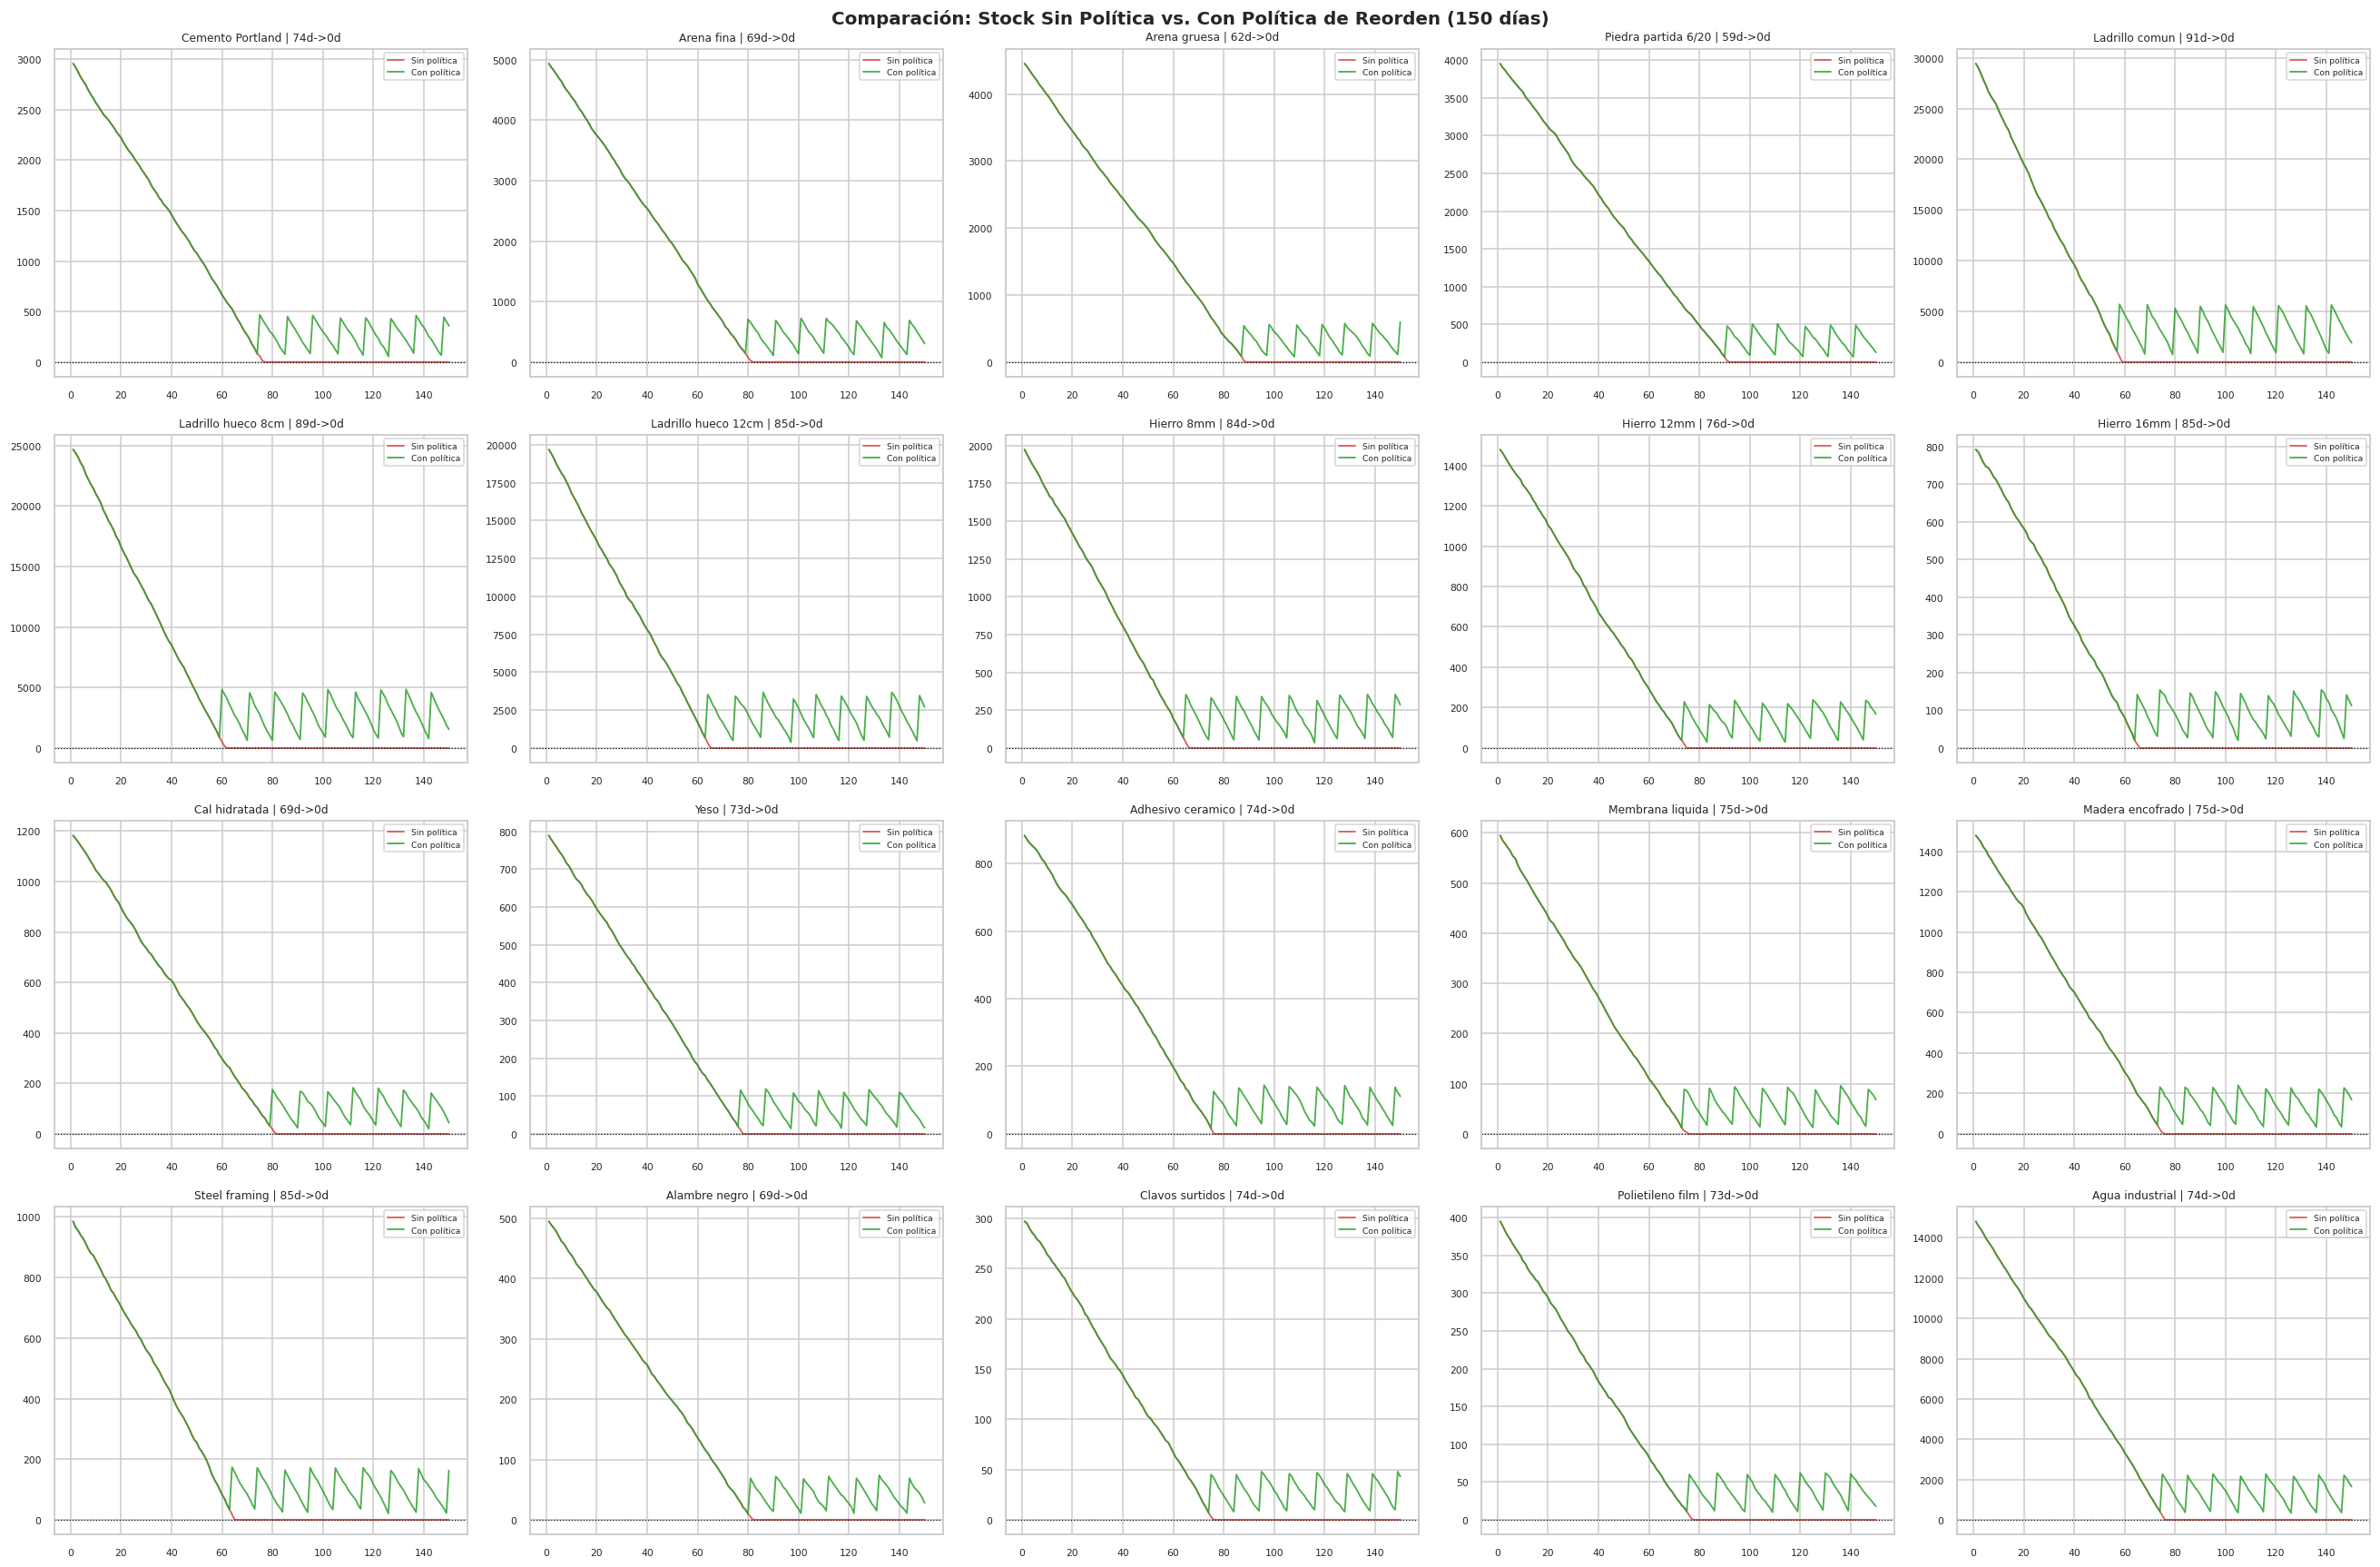

In [ ]:
# ── Gráficos de evaluación ────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 5, figsize=(24, 16))
axes = axes.flatten()

for i, mat in enumerate(materiales_lista):
    sub = df_sim[df_sim["Material"] == mat]
    axes[i].plot(sub["Dia"], sub["Stock_SP"], color="#d62728", lw=1.2, alpha=0.75, label="Sin política")
    axes[i].plot(sub["Dia"], sub["Stock_CP"], color="#2ca02c", lw=1.2, alpha=0.85, label="Con política")
    axes[i].axhline(0, color="black", lw=0.8, ls=":")
    d_sin = int(sub["Desabasto_SP"].sum())
    d_con = int(sub["Desabasto_CP"].sum())
    axes[i].set_title(f"{mat} | {d_sin}d->{d_con}d", fontsize=8)
    axes[i].legend(fontsize=6, loc="upper right")
    axes[i].tick_params(labelsize=7)

fig.suptitle("Comparación: Stock Sin Política vs. Con Política de Reorden (150 días)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("evaluacion_simulacion.png", bbox_inches="tight")
plt.show()


/tmp/ipykernel_3598/2381852000.py:26: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3598/2381852000.py:27: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("pedido_optimizado.png", bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


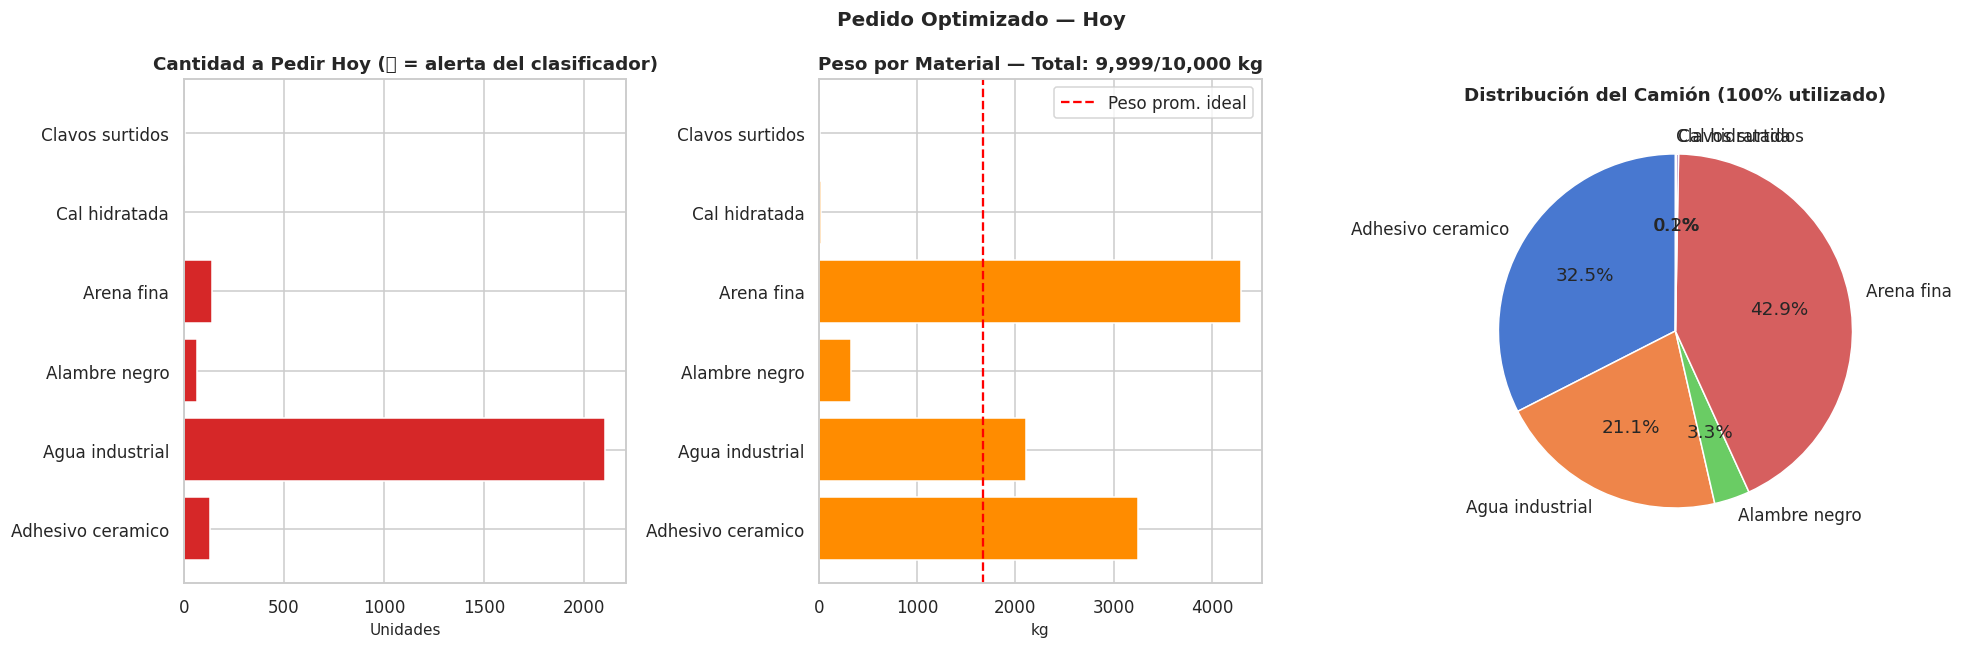

In [ ]:
# ── Gráfico final: pedido optimizado del día ──────────────────────────────────
if not df_pedido.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Barras horizontales: cantidad a pedir
    axes[0].barh(df_pedido["Material"], df_pedido["Cant_a_pedir"],
                 color=["#d62728" if a else "steelblue" for a in df_pedido["Alerta_CLF"]],
                 edgecolor="white")
    axes[0].set_title("Cantidad a Pedir Hoy (🔴 = alerta del clasificador)", fontweight="bold")
    axes[0].set_xlabel("Unidades")

    # Barras: peso en kg
    axes[1].barh(df_pedido["Material"], df_pedido["Peso_total_kg"],
                 color="darkorange", edgecolor="white")
    axes[1].axvline(CAPACIDAD_KG / len(df_pedido), color="red", ls="--", lw=1.5, label="Peso prom. ideal")
    axes[1].set_title(f"Peso por Material — Total: {peso_viaje:,.0f}/{CAPACIDAD_KG:,} kg", fontweight="bold")
    axes[1].set_xlabel("kg"); axes[1].legend()

    # Torta: distribución del peso
    axes[2].pie(df_pedido["Peso_total_kg"], labels=df_pedido["Material"],
                autopct="%1.1f%%", startangle=90,
                colors=sns.color_palette("muted", len(df_pedido)))
    axes[2].set_title(f"Distribución del Camión ({utilizacion:.0f}% utilizado)", fontweight="bold")

    plt.suptitle("Pedido Optimizado — Hoy", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("pedido_optimizado.png", bbox_inches="tight")
    plt.show()


## 8. Conclusiones
### ✅ Lo que construimos

| Componente | Técnica | Resultado |
|---|---|---|
| EDA | Estadísticas + 4 familias de gráficos | Diagnóstico completo del inventario |
| Feature Engineering | Variables de rezago + criticidad | Input rico para los modelos |
| Alerta de desabasto | Random Forest | F1-Score como métrica correcta |
| Pronóstico | Regresión Lineal | Detección de tendencia |
| Política de pedido | ROP + Stock de Seguridad (95%) | Cantidad óptima por material |
| Optimización del viaje | Algoritmo Greedy por urgencia | Respeta los 10.000 kg del camión |
| Evaluación | Nivel de servicio, Fill Rate, Utilización | Métricas con sentido de negocio |
